In [1]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [2]:
import warnings
warnings.filterwarnings("ignore", category = FutureWarning)

In [3]:
import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize = (12, 8), sharex = True)

    axes[0].plot(pd.to_datetime(stock_data_specific.Date), 
                 stock_data_specific.Close.astype("float"),
                 label = "Share Price", color = "blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    axes[1].plot(pd.to_datetime(revenue_data_specific.Date),
                 revenue_data_specific.Revenue.astype("float"),
                 label = "Revenue", color = "green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Share Price")

    plt.tight_layout()
    plt.show()

In [ ]:
tesla = yf.Ticker("TSLA")

In [ ]:
tesla_data = tesla.history(period = "max")

In [ ]:
tesla_data.reset_index(inplace = True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [7]:
import requests

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"

response = requests.get(url)

html_data = response.text

In [8]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(html_data, "html.parser")

In [10]:
import pandas as pd

revenue_data = []

for row in soup.find_all("tbody")[1].find_all("tr"):
    col = row.find_all("td")
    date = col[0].text
    revenue = col[1].text

    revenue_data.append({"Date": date, "Revenue": revenue})

tesla_revenue = pd.DataFrame(revenue_data)

print(tesla_revenue.head())

         Date  Revenue
0  2022-09-30  $21,454
1  2022-06-30  $16,934
2  2022-03-31  $18,756
3  2021-12-31  $17,719
4  2021-09-30  $13,757


In [11]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$', "", regex = True)

In [12]:
tesla_revenue.dropna(inplace = True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

In [13]:
tesla_revenue.tail()

,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


In [14]:
import yfinance as yf

gamestop = yf.Ticker("GME")

In [15]:
gme_data = gamestop.history(period = "max")

In [16]:
gme_data.reset_index(inplace = True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [17]:
import requests

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"

response = requests.get(url)

html_data_2 = response.text

In [18]:
soup = BeautifulSoup(html_data_2, "html.parser")

In [19]:
revenue_data_2 = []

for row in soup.find_all("tbody")[1].find_all("tr"):
    col = row.find_all("td")
    date = col[0].text
    revenue = col[1].text

    revenue_data_2.append({"Date": date, "Revenue": revenue})

gme_revenue = pd.DataFrame(revenue_data_2)

print(gme_revenue.head())

         Date Revenue
0  2020-04-30  $1,021
1  2020-01-31  $2,194
2  2019-10-31  $1,439
3  2019-07-31  $1,286
4  2019-04-30  $1,548


In [20]:
gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(',|\$', "", regex = True)

gme_revenue.dropna(inplace = True)

gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

In [21]:
gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


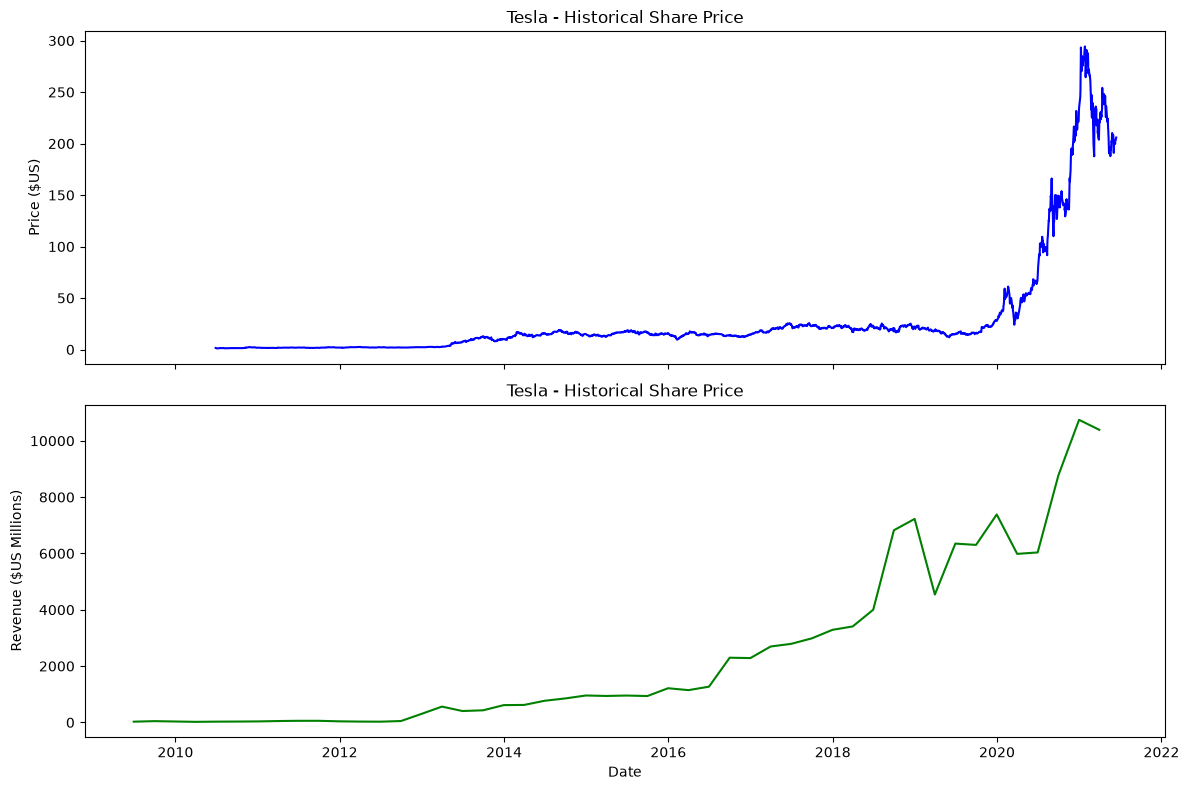

In [22]:
make_graph(tesla_data, tesla_revenue, 'Tesla')

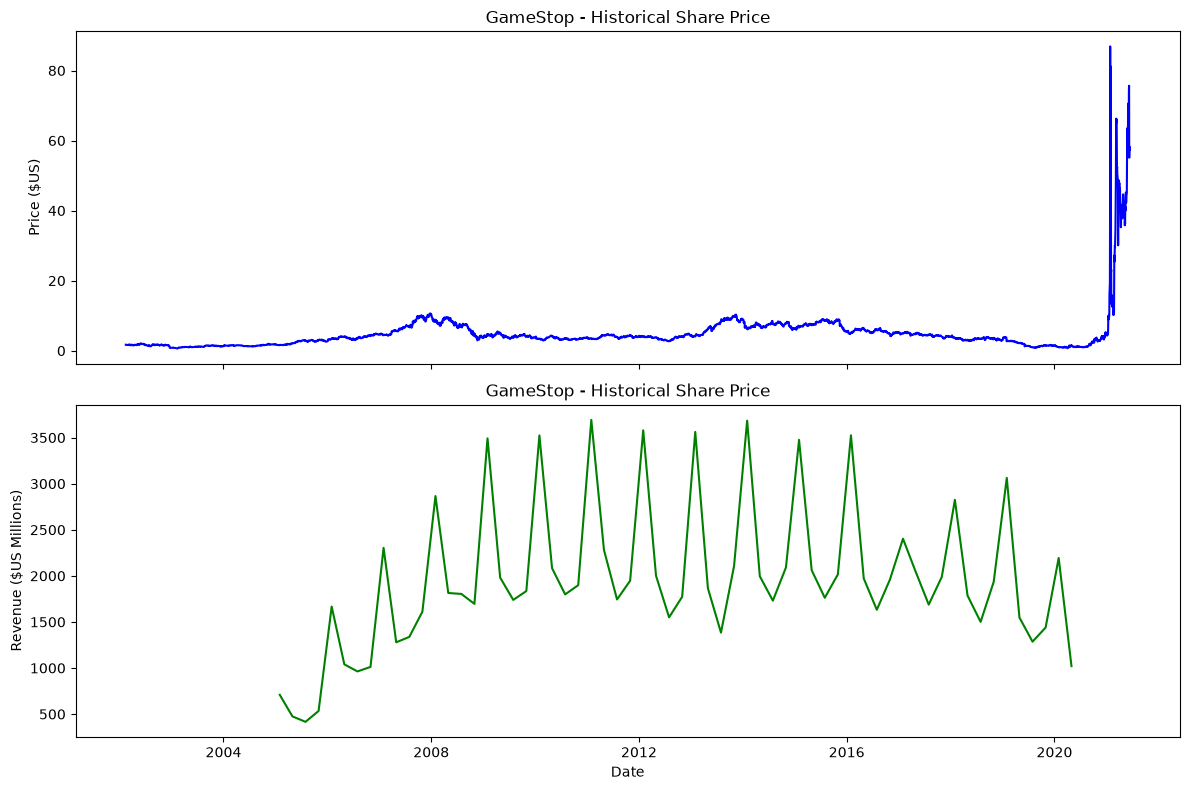

In [23]:
make_graph(gme_data, gme_revenue, 'GameStop')